Question 10

a)

In [25]:
import numpy as np
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]
])
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]

print(returns)
print(returns.shape)

[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]
(2, 11)


b)

In [26]:
mean_annual = np.mean(returns, axis=1) * 12
std_annual = np.std(returns, axis=1, ddof=1) * np.sqrt(12)

print(mean_annual)
print(std_annual)

[0.39087388 0.20073826]
[0.20199403 0.14582022]


c)

In [27]:
cov_matrix = np.cov(returns)
corr_matrix = np.corrcoef(returns)

sigma_a = np.std(returns[0], ddof=1)
sigma_b = np.std(returns[1], ddof=1)

rho = corr_matrix[0, 1]
value = rho * sigma_a * sigma_b

print(cov_matrix)
print(value)
print(cov_matrix[0, 1])

[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]
-0.0020642605060094284
-0.0020642605060094284


Question 11

a)

In [28]:


mu = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])

corr = np.array([
    [1.0, 0.4, 0.1],
    [0.4, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])

cov_matrix = np.outer(sigma, sigma) * corr
w = np.array([1/3, 1/3, 1/3])

portfolio_return = w @ mu
portfolio_variance = w @ cov_matrix @ w

print(portfolio_return)
print(portfolio_variance)

0.09333333333333332
0.011824444444444443


b)

In [29]:
weights = np.random.dirichlet([1, 1, 1], 10000)
portfolio_returns = weights @ mu
portfolio_variance = np.einsum('ij,jk,ik->i', weights, cov_matrix, weights)
portfolio_std = np.sqrt(portfolio_variance)

print(portfolio_returns.shape)
print(portfolio_std.shape)

(10000,)
(10000,)


c)

In [30]:
risk_free_rate = 0.04
sharpe_ratio = (portfolio_returns - risk_free_rate) / portfolio_std
max_index = np.argmax(sharpe_ratio)

print(sharpe_ratio[max_index])
print(weights[max_index])

0.5053333994416819
[0.19742155 0.17539888 0.62717958]


Question 12

a)

In [31]:
import numpy as np

mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.6
w2 = 0.4

rho = np.linspace(-1, 1, 200)

portfolio_variance = (
    (w1 ** 2) * (sigma1 ** 2) +
    (w2 ** 2) * (sigma2 ** 2) +
    2 * w1 * w2 * rho * sigma1 * sigma2
)
portfolio_std = np.sqrt(portfolio_variance)

print(portfolio_std)
print(portfolio_std.shape)

[0.08       0.08060076 0.08119707 0.08178904 0.08237675 0.0829603
 0.08353978 0.08411526 0.08468683 0.08525457 0.08581855 0.08637885
 0.08693554 0.08748869 0.08803837 0.08858463 0.08912754 0.08966717
 0.09020357 0.09073679 0.09126691 0.09179396 0.092318   0.09283908
 0.09335726 0.09387257 0.09438508 0.09489481 0.09540182 0.09590615
 0.09640784 0.09690694 0.09740348 0.0978975  0.09838903 0.09887813
 0.09936482 0.09984913 0.10033111 0.10081078 0.10128819 0.10176335
 0.1022363  0.10270708 0.10317571 0.10364221 0.10410663 0.10456899
 0.10502931 0.10548762 0.10594395 0.10639832 0.10685076 0.10730129
 0.10774994 0.10819673 0.10864168 0.10908482 0.10952616 0.10996573
 0.11040355 0.11083965 0.11127403 0.11170672 0.11213775 0.11256712
 0.11299486 0.11342099 0.11384553 0.11426848 0.11468988 0.11510974
 0.11552806 0.11594488 0.11636021 0.11677406 0.11718645 0.11759739
 0.1180069  0.11841499 0.11882169 0.11922699 0.11963092 0.1200335
 0.12043472 0.12083462 0.12123319 0.12163046 0.12202644 0.122421

b)

In [32]:
min_index = np.argmin(portfolio_std)

print(rho[min_index])
print(portfolio_std[min_index])

-1.0
0.08000000000000002


c) Minimum variance occurs at rho = -1

In [40]:
derivative = 2 * w1 * w2 * sigma1 * sigma2

print(derivative)


0.009600000000000001


Question 13

a)

In [41]:
import pandas as pd
import numpy as np

np.random.seed(0)

dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

returns_df = df.pct_change().dropna()

print(returns_df.head(3))
print(returns_df.shape)

                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
(51, 4)


b)

In [42]:
description = returns_df.describe()
highest_mean = returns_df.mean().idxmax()
highest_std = returns_df.std().idxmax()

print(description)
print(highest_mean)
print(highest_std)

            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269
AMZN
AAPL


c)

In [43]:
risk_free_rate = 0.02

annual_return = returns_df.mean() * 52
annual_std = returns_df.std() * np.sqrt(52)
sharpe_ratio = (annual_return - risk_free_rate) / annual_std

print(sharpe_ratio)

AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64


Question 14

a)

In [44]:
corr_matrix = returns_df.corr()

lowest_pair = corr_matrix.where(
    ~np.eye(corr_matrix.shape[0], dtype=bool)
).stack().idxmin()

print(corr_matrix)
print(lowest_pair)

           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000
('AAPL', 'MSFT')


b)

In [45]:
weights = pd.Series(
    [0.25, 0.25, 0.25, 0.25],
    index=['AAPL', 'MSFT', 'GOOGL', 'AMZN']
)

portfolio_returns = returns_df.dot(weights)

print(portfolio_returns.head())

2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64


c)

In [46]:
monthly_returns = portfolio_returns.resample('ME').apply(
    lambda x: (1 + x).prod() - 1
)

print(monthly_returns.mean())
print(monthly_returns.std())

0.013974973306651484
0.039023369077949295


Question 15

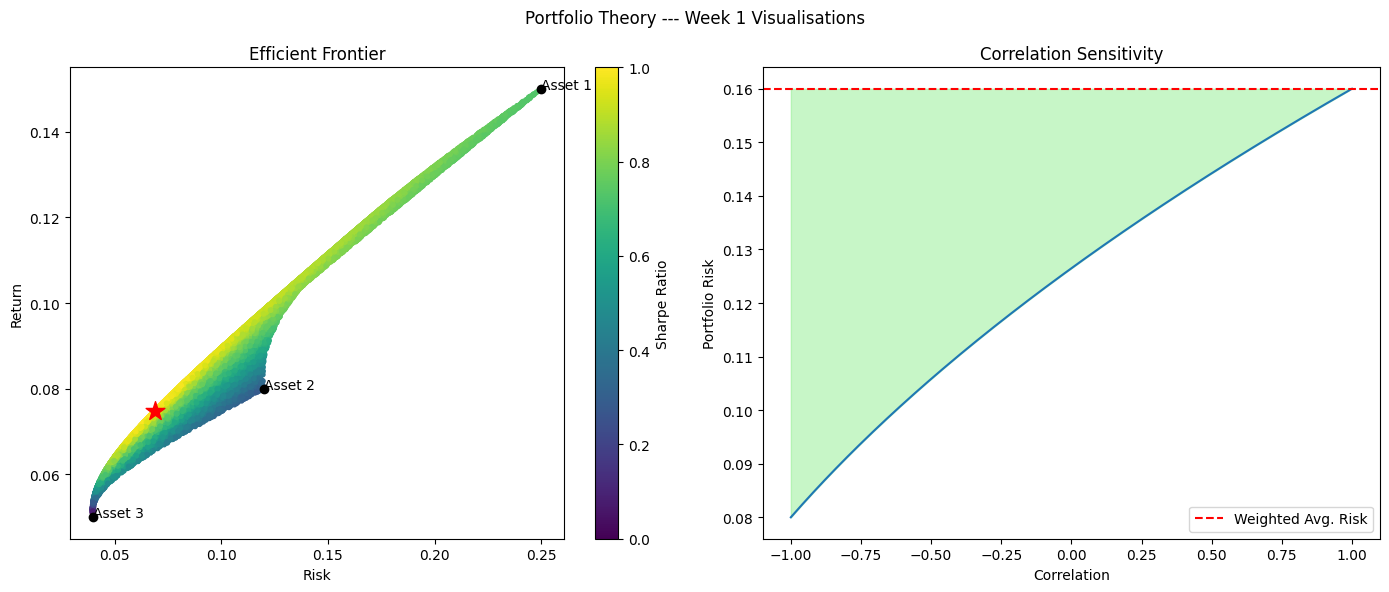

In [47]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
mu = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])

corr = np.array([
    [1.0, 0.4, 0.1],
    [0.4, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])

cov_matrix = np.outer(sigma, sigma) * corr
weights = np.random.dirichlet([1, 1, 1], 20000)
portfolio_returns = weights @ mu
portfolio_variance = np.einsum('ij,jk,ik->i', weights, cov_matrix, weights)
portfolio_std = np.sqrt(portfolio_variance)
risk_free_rate = 0.04
sharpe_ratio = (portfolio_returns - risk_free_rate) / portfolio_std
max_index = np.argmax(sharpe_ratio)

rho = np.linspace(-1, 1, 200)

mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.6
w2 = 0.4

portfolio_var_2 = (
    (w1**2)*(sigma1**2) +
    (w2**2)*(sigma2**2) +
    2*w1*w2*rho*sigma1*sigma2
)

portfolio_std_2 = np.sqrt(portfolio_var_2)
weighted_avg_risk = w1*sigma1 + w2*sigma2
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(
    portfolio_std,
    portfolio_returns,
    c=sharpe_ratio,
    cmap='viridis',
    s=10
)

ax[0].scatter(
    portfolio_std[max_index],
    portfolio_returns[max_index],
    color='red',
    marker='*',
    s=200
)

ax[0].scatter(sigma, mu, color='black')

ax[0].text(sigma[0], mu[0], 'Asset 1')
ax[0].text(sigma[1], mu[1], 'Asset 2')
ax[0].text(sigma[2], mu[2], 'Asset 3')

ax[0].set_xlabel('Risk')
ax[0].set_ylabel('Return')
ax[0].set_title('Efficient Frontier')

fig.colorbar(
    plt.cm.ScalarMappable(cmap='viridis'),
    ax=ax[0],
    label='Sharpe Ratio'
)

ax[1].plot(rho, portfolio_std_2)

ax[1].axhline(
    weighted_avg_risk,
    color='red',
    linestyle='--',
    label='Weighted Avg. Risk'
)

ax[1].fill_between(
    rho,
    portfolio_std_2,
    weighted_avg_risk,
    where=portfolio_std_2 < weighted_avg_risk,
    color='lightgreen',
    alpha=0.5
)

ax[1].set_xlabel('Correlation')
ax[1].set_ylabel('Portfolio Risk')
ax[1].set_title('Correlation Sensitivity')
ax[1].legend()

plt.suptitle('Portfolio Theory --- Week 1 Visualisations')
plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150)
plt.show()